In [1]:
import grewpy
from grewpy import Corpus, CorpusDraft, Request
from collections import Counter
import pandas as pd

import sys
sys.path.insert(1, "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod")

import tod.corpus
import tod.outliers
import tod.clustering
import tod.plotting
import tod.dimension_reduction_classic

GREW_PATTERN = "pattern{X[upos<>PUNCT]}"
PATTERNS_TEXT_FILE = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/3. probability_matrix/patterns_all_nodes.txt"
UD_UPOS_LIST = [
    'ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'NOUN', 'NUM', 
    'PART', 'PRON', 'PROPN', 'SCONJ', 'SYM', 'VERB', 'INTJ', 'X'
]

connected to port: 62969


In [2]:
def get_inventory_matrix(corpus):
    binary_matrix = {}
    features = corpus._idx2feature
    uposes = set()
    for k, v in features.items():
        if "upos" in v:
            upos = v.split("upos=")[1]
            uposes.add(upos)
    for upos in UD_UPOS_LIST:
        binary_matrix[upos] = 1 if upos in uposes else 0
    return binary_matrix


In [43]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def get_transition_matrix(corpus):
    similarity_matrix = cosine_similarity(corpus.feature_matrix)
    lang_stats = pd.DataFrame(0.0, index=UD_UPOS_LIST, columns=UD_UPOS_LIST)
    counts = {cat: 0 for cat in UD_UPOS_LIST}

    for idx, lex_unit in corpus._idx2lexunit.items():
        current_category = lex_unit[1]
        if current_category not in UD_UPOS_LIST:
            continue

        counts[current_category] += 1

        threshold_indices = np.where(similarity_matrix[idx] > 0.7)[0]
        high_similarity_indices = sorted(
        [n_idx for n_idx in threshold_indices if n_idx != idx],
        key=lambda x: similarity_matrix[idx][x],
        reverse=True
    )[:20]

        sum_all_weights = sum(similarity_matrix[idx][n_idx] for n_idx in high_similarity_indices)
        
        if sum_all_weights == 0:
            continue

        for n_idx in high_similarity_indices:
            neighbour_category = corpus._idx2lexunit[n_idx][1]
            if neighbour_category in UD_UPOS_LIST and neighbour_category != current_category:
                weight = similarity_matrix[idx][n_idx] / sum_all_weights
                lang_stats.loc[current_category, neighbour_category] += weight

    # # normalised by the nb of occurrences so that a category that occurs more often doesn't have an unfair advantage in the transition matrix
    # for cat in UD_UPOS_LIST:
    #     if counts[cat] > 0:
    #         lang_stats.loc[cat] = lang_stats.loc[cat] / counts[cat]
    #     else:
    #         lang_stats.loc[cat] = np.nan
    
    # so that the rows sum up to 1 like in the heatmaps 
    row_sums = lang_stats.sum(axis=1)
    lang_stats = lang_stats.div(row_sums, axis=0)

    transition_dico = {}
    for src in UD_UPOS_LIST:
        for tgt in UD_UPOS_LIST:
            transition_dico[f"{src}->{tgt}"] = lang_stats.loc[src, tgt]
    return transition_dico

In [4]:
def get_variance_matrix(corpus):
    lex_units = list(corpus._idx2lexunit.values())
    df_lexunits = pd.DataFrame(lex_units, columns=['lemma', 'pos'])
    
    unique_pos = df_lexunits['pos'].unique()
    variance_dico = {}
    for pos in unique_pos:
        idx = df_lexunits[df_lexunits['pos'] == pos].index.tolist()
        if len(idx) > 1:
            category_vectors = corpus.feature_matrix[idx]
            centroid = np.mean(category_vectors, axis=0)
            squared_diffs = np.square(category_vectors - centroid)
            sum_squared_dist = np.sum(squared_diffs, axis=1)
            variance = np.mean(sum_squared_dist)
            variance_dico[f"{pos}_variance"] = variance
        else:
            variance_dico[f"{pos}_variance"] = np.nan
    return variance_dico
    

In [5]:
def process_treebank(path, language_name):

    corpus = tod.corpus.Corpus(
            treebank_path=path,
            grew_pattern=GREW_PATTERN,
            patterns_text_file=PATTERNS_TEXT_FILE,
            use_sud=False,
            matrix_type="coverage",
            excluded_feature_patterns=[r"own"],
            included_feature_patterns=[r"upos=", 
                                        r"position=", 
                                        r"rel_shallow=",
                                        r"Abbr=", 
                                        r"Aspect=",  
                                        r"Animacy=",  
                                        r"Case=",  
                                        r"Clusivity=",  
                                        r"Definite=",  
                                        r"Deixis=", 
                                        r"DeixisRef",  
                                        r"Evident=",  
                                        r"Negation=",
                                        r"Number=",  
                                        r"Gender=",  
                                        r"Degree=",  
                                        r"ExtPos=", 
                                        r"Foreign=", 
                                        r"Mood",  
                                        r"NounClass=",  
                                        r"NumType=",  
                                        r"Person=",  
                                        r"Polarity=", 
                                        r"Polite=",  
                                        r"Poss=",  
                                        r"PronType=",  
                                        r"Reflex=",  
                                        r"Tense=",  
                                        r"Typo=",     
                                        r"VerbForm=",  
                                        r"Voice=",   ])
    # feature_matrix = corpus.feature_matrix
    row_data = {"Language": language_name}
    inventory_matrix = get_inventory_matrix(corpus)
    row_data.update(inventory_matrix)
    transition_matrix = get_transition_matrix(corpus)
    row_data.update(transition_matrix)
    variance_matrix = get_variance_matrix(corpus)
    row_data.update(variance_matrix)
    return row_data


In [20]:
def select_features(master_matrix, main_category, variance_categories):
    selected_columns = []
    if main_category in master_matrix.columns:
        selected_columns.append(main_category)
    
    target_var = f"{main_category}_variance"
    if target_var in master_matrix.columns:
        selected_columns.append(target_var)
    
    for var_cat in variance_categories:
        
        var_col = f"{var_cat}_variance"
        if var_col in master_matrix.columns:
            selected_columns.append(var_col)
    
    relevant_poses = [main_category] + variance_categories

    for col in master_matrix.columns:
        if "->" in col:
            parts = col.split("->")
            if any(part in relevant_poses for part in parts):
                selected_columns.append(col)
    
    unique_cols = list(dict.fromkeys(selected_columns))

    # remove intj, x and sym because they are not really relevant for the typological classification and they add a lot of noise to the heatmap
    for col in unique_cols.copy():
        # Split the column name into its component parts (e.g., 'AUX_variance' -> ['AUX', 'variance'])
        parts = col.replace('->', '_').split('_')
        if any(pos in parts for pos in ["INTJ", "X", "SYM"]):
            unique_cols.remove(col)
    
    print(f"Selected columns for {main_category}: {unique_cols}")
    return master_matrix[unique_cols]
                


In [44]:
from tqdm.auto import tqdm
import os
treebanks_folder = "/Users/madalina/Documents/PHD/code/data/small_test"
# treebanks_folder = "/Users/madalina/Documents/PHD/code/data/single_treebank"
treebanks = [t for t in os.listdir(treebanks_folder) if t.startswith("UD_")]

all_language_data = []
for treebank in tqdm(treebanks, desc="Processing treebanks"):
    print(f"Processing {treebank}...")
    full_path = os.path.join(treebanks_folder, treebank)
    try:
        lang_name_list = treebank.split("_")[1:]
        new_s = "_".join(lang_name_list)
        master_matrix_row = process_treebank(full_path, new_s)
        all_language_data.append(master_matrix_row)
    except Exception as e:
        print(f"Failed {treebank}: {e}")

Processing treebanks:   0%|          | 0/6 [00:00<?, ?it/s]

Processing UD_Indonesian-GSD...
Processing UD_Italian-ISDT...
Processing UD_Korean-GSD...
Processing UD_Wolof-WTB...
Processing UD_Japanese-GSD...
Processing UD_French-GSD...


In [45]:
master_df = pd.DataFrame(all_language_data).set_index("Language")
master_df

,ADJ,ADP,ADV,AUX,CCONJ,DET,NOUN,NUM,PART,PRON,...,ADP_variance,SCONJ_variance,ADV_variance,ADJ_variance,PRON_variance,CCONJ_variance,DET_variance,PART_variance,INTJ_variance,X_variance
Language,,,,,,,,,,,,,,,,,,,,,
Indonesian-GSD,1,1,1,1,1,1,1,1,1,1,...,0.018848,0.012121,0.021868,0.015636,0.021220,0.010373,0.034775,0.022418,NaN,NaN
Italian-ISDT,1,1,1,1,1,1,1,1,0,1,...,0.008616,0.007334,0.011457,0.014523,0.012901,0.008176,0.018027,NaN,0.001369,NaN
Korean-GSD,1,1,1,1,1,1,1,1,1,1,...,0.041455,NaN,0.038632,0.059169,0.042141,0.047308,0.015951,NaN,NaN,NaN
Wolof-WTB,0,1,1,1,1,1,1,1,1,1,...,0.029851,0.006820,0.012101,NaN,0.012010,0.009861,0.028360,NaN,NaN,NaN
Japanese-GSD,1,1,1,1,1,1,1,1,1,1,...,0.013690,0.060876,0.029684,0.032105,0.019608,0.028230,0.004188,0.052866,NaN,NaN
French-GSD,1,1,1,1,1,1,1,1,0,1,...,0.011312,0.002491,0.011169,0.018933,0.013720,0.015169,0.016239,NaN,0.021580,NaN


In [46]:
import numpy as np
import pandas as pd

def manual_gower_matrix(df, cat_cols):
    """
    Computes Gower distance matrix handling NaNs gracefully.
    df: DataFrame with languages as rows
    cat_cols: List of column names to treat as categorical (0/1)
    """
    n = df.shape[0]
    dist_matrix = np.zeros((n, n))
    
    # Pre-calculate ranges for numerical columns to save time
    num_cols = [c for c in df.columns if c not in cat_cols]
    col_ranges = df[num_cols].max() - df[num_cols].min()
    
    # Convert to numpy for speed
    data = df.values
    col_names = list(df.columns)
    cat_indices = [col_names.index(c) for c in cat_cols]
    num_indices = [col_names.index(c) for c in num_cols]

    for i in range(n):
        for j in range(i + 1, n):
            similarities = []
            weights = []
            
            for idx in range(df.shape[1]):
                val_i = data[i, idx]
                val_j = data[j, idx]
                
                # Skip if either is NaN
                if pd.isna(val_i) or pd.isna(val_j):
                    continue
                
                if idx in cat_indices:
                    # Categorical: 1 if same, 0 if different
                    s = 1.0 if val_i == val_j else 0.0
                else:
                    # Numerical: 1 - normalized diff
                    col_range = col_ranges.iloc[num_indices.index(idx)]
                    if col_range == 0:
                        s = 1.0 # They are the same and range is 0
                    else:
                        s = 1.0 - (abs(val_i - val_j) / col_range)
                
                similarities.append(s)
                weights.append(1.0)
            
            if sum(weights) == 0:
                # Total fallback if NO columns overlap
                dist_matrix[i, j] = dist_matrix[j, i] = 1.0
            else:
                sim = sum(similarities) / sum(weights)
                dist_matrix[i, j] = dist_matrix[j, i] = 1.0 - sim
                
    return dist_matrix

# Usage:
# dist_matrix = manual_gower_matrix(filtered_df, cat_cols=['ADJ'])

In [82]:

main_comparison_category = "ADJ"
variance_categories = ["NOUN", "VERB"]

pos_df = select_features(master_df, main_comparison_category, variance_categories)
cat_features_mask = [col == main_comparison_category for col in pos_df.columns]
# pos_df = pos_df.loc[:, pos_df.nunique(dropna=True) > 1]
distance_matrix = manual_gower_matrix(pos_df, cat_cols=[main_comparison_category])


Selected columns for ADJ: ['ADJ', 'ADJ_variance', 'NOUN_variance', 'VERB_variance', 'ADJ->ADJ', 'ADJ->ADP', 'ADJ->ADV', 'ADJ->AUX', 'ADJ->CCONJ', 'ADJ->DET', 'ADJ->NOUN', 'ADJ->NUM', 'ADJ->PART', 'ADJ->PRON', 'ADJ->PROPN', 'ADJ->SCONJ', 'ADJ->VERB', 'ADP->ADJ', 'ADP->NOUN', 'ADP->VERB', 'ADV->ADJ', 'ADV->NOUN', 'ADV->VERB', 'AUX->ADJ', 'AUX->NOUN', 'AUX->VERB', 'CCONJ->ADJ', 'CCONJ->NOUN', 'CCONJ->VERB', 'DET->ADJ', 'DET->NOUN', 'DET->VERB', 'NOUN->ADJ', 'NOUN->ADP', 'NOUN->ADV', 'NOUN->AUX', 'NOUN->CCONJ', 'NOUN->DET', 'NOUN->NOUN', 'NOUN->NUM', 'NOUN->PART', 'NOUN->PRON', 'NOUN->PROPN', 'NOUN->SCONJ', 'NOUN->VERB', 'NUM->ADJ', 'NUM->NOUN', 'NUM->VERB', 'PART->ADJ', 'PART->NOUN', 'PART->VERB', 'PRON->ADJ', 'PRON->NOUN', 'PRON->VERB', 'PROPN->ADJ', 'PROPN->NOUN', 'PROPN->VERB', 'SCONJ->ADJ', 'SCONJ->NOUN', 'SCONJ->VERB', 'VERB->ADJ', 'VERB->ADP', 'VERB->ADV', 'VERB->AUX', 'VERB->CCONJ', 'VERB->DET', 'VERB->NOUN', 'VERB->NUM', 'VERB->PART', 'VERB->PRON', 'VERB->PROPN', 'VERB->SCONJ', 'V

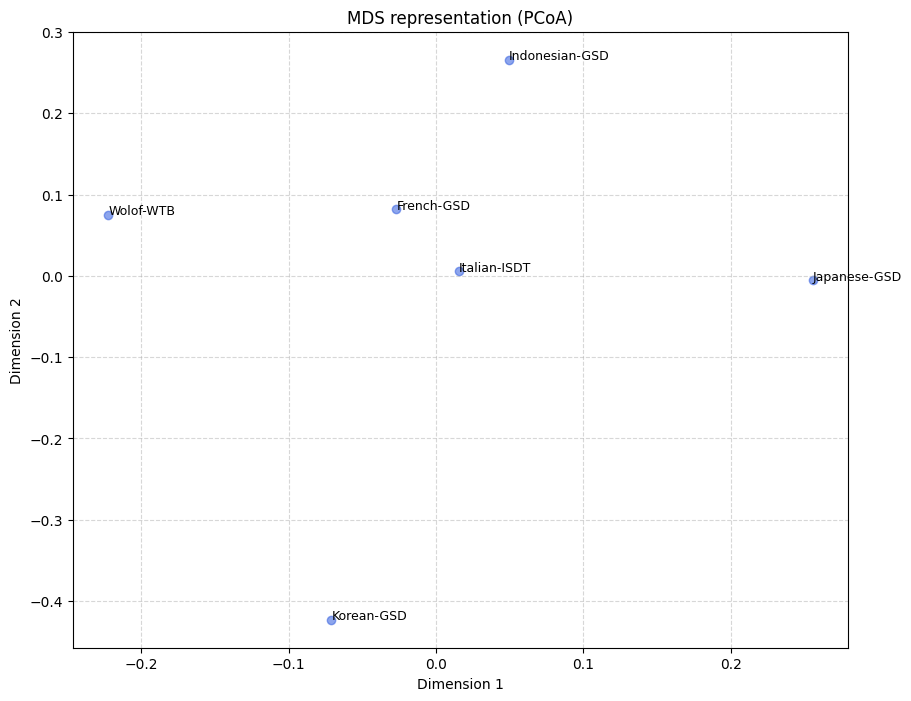

In [89]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

# 1. Initialize MDS (MDS with 'precomputed' dissimilarity is PCoA)
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)

# 2. Fit and transform the Gower distance matrix
coords = mds.fit_transform(distance_matrix)

# 3. Plot the results
plt.figure(figsize=(10, 8))
plt.scatter(coords[:, 0], coords[:, 1], c='royalblue', alpha=0.6)

# Annotate each point with the language name
for i, lang_name in enumerate(master_df.index):
    plt.annotate(lang_name, (coords[i, 0], coords[i, 1]), fontsize=9)

plt.title("MDS representation (PCoA)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

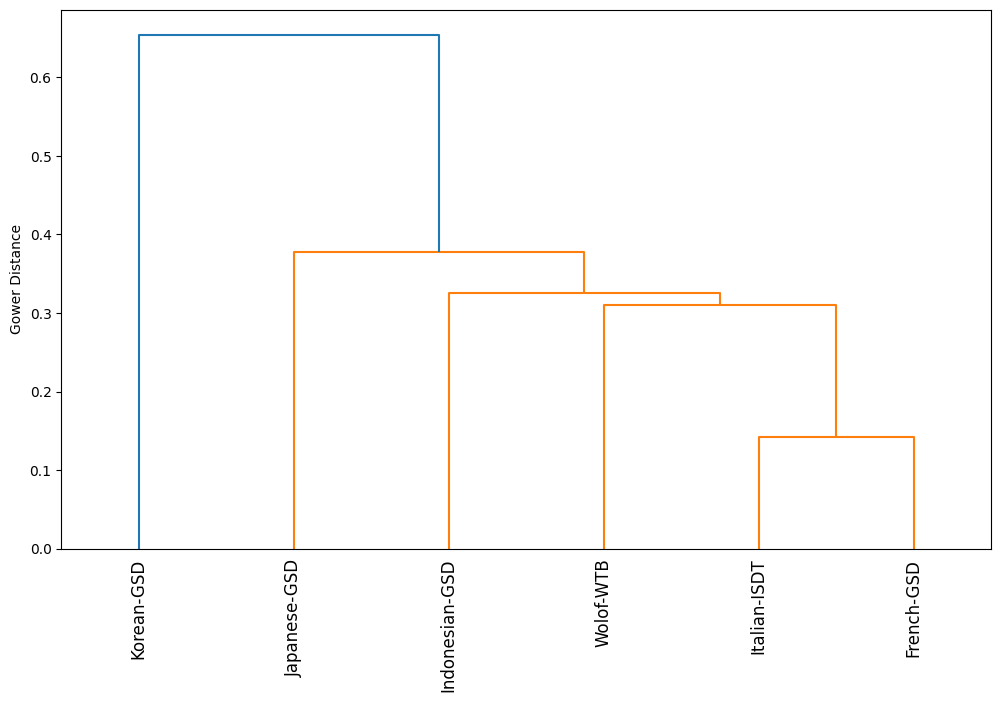

In [88]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# 1. Convert the distance matrix to 'condensed' form for SciPy
# (Ensures the matrix is symmetric and zeros on the diagonal)
condensed_dist = squareform(distance_matrix, force='tovector')

# 2. Perform Linkage (Ward's method is usually best for clusters)
Z = linkage(condensed_dist, method='ward')

# 3. Plot the Dendrogram
plt.figure(figsize=(12, 7))
dendrogram(Z, labels=master_df.index, leaf_rotation=90)
# plt.title("Hierarchical Typology of Languages")
plt.ylabel("Gower Distance")
plt.show()

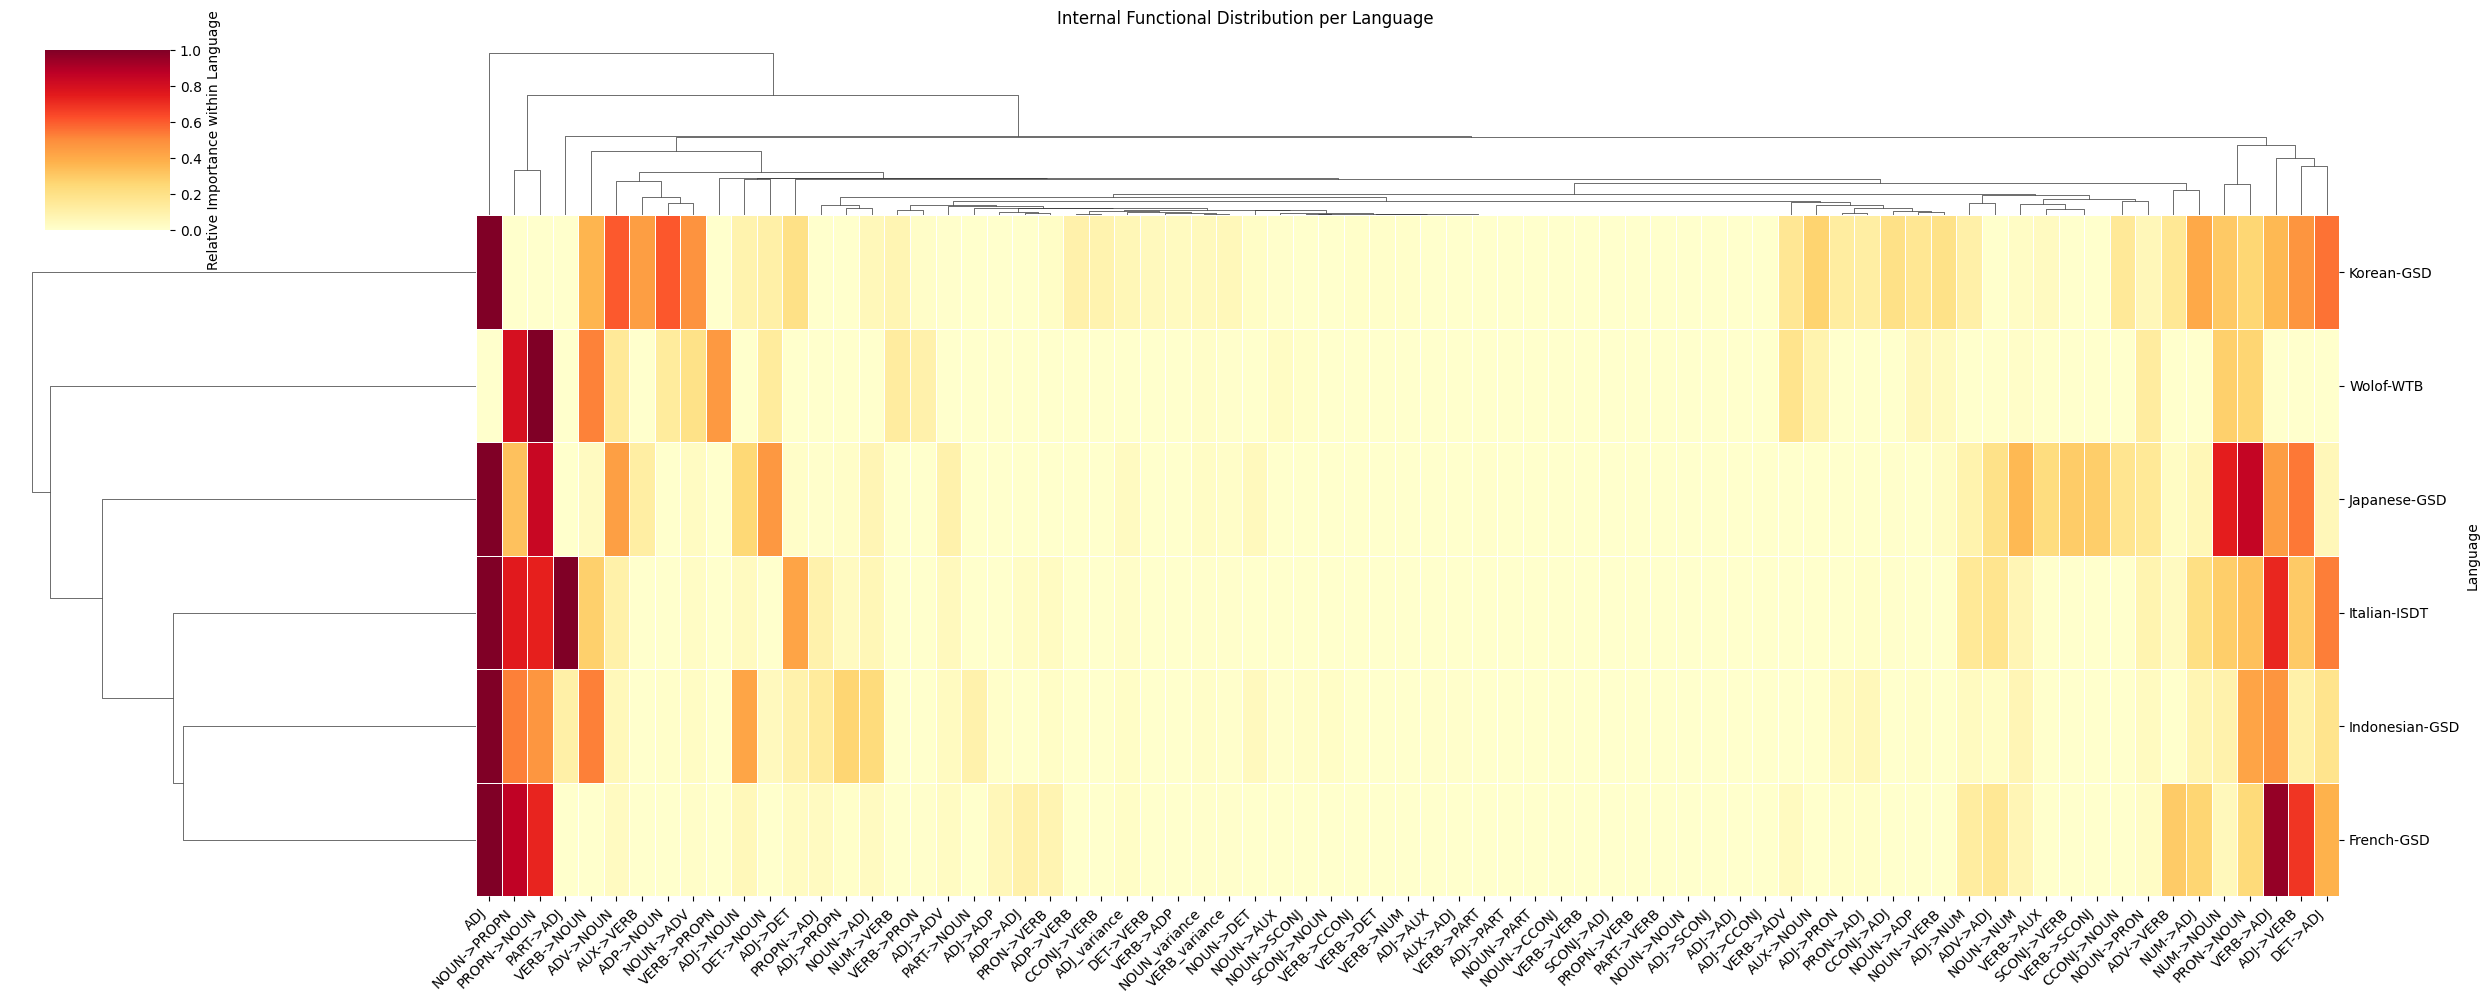

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import Normalizer

def plot_typological_heatmap(df):
    """
    df: The filtered_df containing the 6 languages and selected features.
    """
    # 1. Handle NaNs: To plot, we usually fill NaNs with 0 or a 'missing' color.
    # For a heatmap, 0 is often best to show the 'absence' of a feature.
    plot_data = df.fillna(0)
    
    # 2. Normalize features (0 to 1 scale) so columns are comparable
    scaler = Normalizer(norm='max')
    # .T flips it so languages are columns, we scale, then flip back
    row_scaled_data = scaler.fit_transform(plot_data)
    
    normalized_df = pd.DataFrame(
        row_scaled_data, 
        columns=plot_data.columns, 
        index=plot_data.index
    )
    
    # 3. Create Heatmap
    g = sns.clustermap(
        normalized_df, 
        cmap='YlOrRd', 
        linewidths=.7, 
        figsize=(25, 10),
        cbar_kws={'label': 'Relative Importance within Language'}
    )
    
    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, horizontalalignment='right')
    g.fig.suptitle('Internal Functional Distribution per Language', y=1.02)
    plt.show()

# Run the plot
plot_typological_heatmap(pos_df)

In [60]:
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler

def plot_typological_heatmap_interactive(df):
    """
    Interactive heatmap with hover information showing feature names.
    df: The filtered_df containing languages and selected features.
    """
    # 1. Handle NaNs
    plot_data = df.fillna(0)
    
    # 2. Normalize features (0 to 1 scale)
    scaler = Normalizer(norm='max')
    normalized_data = pd.DataFrame(
        scaler.fit_transform(plot_data), 
        columns=plot_data.columns, 
        index=plot_data.index
    )
    
    # 3. Create hover text matrix
    hover_text = []
    for lang_idx, lang in enumerate(normalized_data.index):
        hover_row = []
        for feat_idx, feat in enumerate(normalized_data.columns):
            original_value = plot_data.iloc[lang_idx, feat_idx]
            normalized_value = normalized_data.iloc[lang_idx, feat_idx]
            hover_row.append(
                f"Language: {lang}<br>"
                f"Feature: {feat}<br>"
                f"Original Value: {original_value:.4f}<br>"
                f"Normalized: {normalized_value:.4f}"
            )
        hover_text.append(hover_row)
    
    # 4. Create Plotly heatmap
    fig = go.Figure(data=go.Heatmap(
        z=normalized_data.values,
        x=normalized_data.columns,
        y=normalized_data.index,
        colorscale='YlOrRd',  # or 'Blues', 'Plasma', etc.
        hovertext=hover_text,
        hoverinfo='text',
        colorbar=dict(title='Normalized<br>Intensity')
    ))
    
    fig.update_layout(
        title='Interactive Feature Footprints by Language',
        xaxis_title='Features',
        yaxis_title='Languages',
        width=1400,
        height=800,
        xaxis=dict(tickangle=45, tickfont=dict(size=10)),
        yaxis=dict(tickfont=dict(size=10))
    )
    
    fig.show()

# Run the interactive plot
plot_typological_heatmap_interactive(pos_df)

In [86]:
import plotly.graph_objects as go
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from sklearn.preprocessing import Normalizer
import pandas as pd

def plot_full_interactive_heatmap(pos_df, dist_matrix):
    """
    Shows ALL features from pos_df, but ordered by the dendrogram logic.
    """
    # 1. Handle NaNs for the full dataset
    plot_data = pos_df.fillna(0)
    
    # 2. Reorder Rows (Languages) based on the distance matrix
    # This ensures Wolof, French, etc. stay in their typological groups
    condensed_dist = squareform(dist_matrix, force='tovector')
    Z = linkage(condensed_dist, method='ward')
    order = leaves_list(Z)
    
    ordered_df = plot_data.iloc[order]
    
    # 3. Row-wise Normalization (so we can see French ADJ-ADP vs ADJ-VERB)
    scaler = Normalizer(norm='max')
    normalized_values = scaler.fit_transform(ordered_df)
    
    # 4. Create the Plotly figure
    fig = go.Figure(data=go.Heatmap(
        z=normalized_values,
        x=ordered_df.columns,
        y=ordered_df.index,
        colorscale='YlOrRd',
        # customdata stores the original unscaled weights for the hover
        customdata=ordered_df.values,
        hovertemplate=(
            "<b>Language:</b> %{y}<br>" +
            "<b>Feature:</b> %{x}<br>" +
            "<b>Normalized Intensity:</b> %{z:.4f}<br>" +
            "<b>Original Value:</b> %{customdata:.4f}<extra></extra>"
        )
    ))
    
    fig.update_layout(
        title='Full Interactive Feature Footprints (Clustered Order)',
        xaxis_title='All Treebank Features',
        yaxis_title='Languages',
        width=1600, # Increased width to accommodate more features
        height=800,
        xaxis=dict(tickangle=45, tickfont=dict(size=8)) # Smaller font for many features
    )
    
    fig.show()

    return fig

# Run with your full dataframe
fig = plot_full_interactive_heatmap(pos_df, distance_matrix)

In [87]:
fig.write_html("/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/29. polycategoriality/typological_heatmap_6langs.html")

In [67]:
import plotly.express as px
import pandas as pd

def plot_variance_comparison(master_df):
    """
    master_df: The matrix containing 'ADJ', 'VERB_variance', 'NOUN_variance', etc.
    """
    # 1. Prepare the label: Language name + Tick/Cross for ADJ
    # Check if 'ADJ' exists and is 1
    labels = []
    for lang, row in master_df.iterrows():
        status = "✓" if row.get('ADJ') == 1 else "✗"
        labels.append(f"{lang} ({status} ADJ)")
    
    # 2. Extract only the variance columns
    var_cols = [c for c in master_df.columns if '_variance' in c]
    plot_df = master_df[var_cols].copy()
    plot_df.index = labels
    
    # 3. Reshape for Plotly (Long format)
    plot_df = plot_df.reset_index().melt(id_vars='index', var_name='Category', value_name='Variance')
    
    # 4. Create the Bar Chart
    fig = px.bar(
        plot_df, 
        x='index', 
        y='Variance', 
        color='Category',
        barmode='group',
        title="Cross-Linguistic Variance Comparison: The 'ADJ' Effect",
        labels={'index': 'Language (Presence of ADJ Tag)', 'Variance': 'Internal Category Variance'}
    )
    
    fig.update_layout(xaxis_tickangle=-45)
    fig.show()

plot_variance_comparison(pos_df)

In [80]:
def plot_enhanced_typological_heatmap(df, dist_matrix):
    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import squareform
    from sklearn.preprocessing import Normalizer, MinMaxScaler
    
    # 1. Cluster and Order
    Z = linkage(squareform(dist_matrix, force='tovector'), method='ward')
    order = leaves_list(Z)
    ordered_df = df.iloc[order].copy()

    # 2. Create the "Tick" Labels
    # Logic: If 'Annotated', use a checkmark; otherwise, use an empty circle
    def format_label(row):
        lang_name = str(row.name)
        status = str(row.get('ADJ', ''))
        icon = "✅" if "1" in status else "⚪"
        return f"{icon} {lang_name}"

    # Apply the new labels to the index for display
    display_names = ordered_df.apply(format_label, axis=1)

    # 3. Separate Columns for Math
    # Only pull numeric columns for scaling
    numeric_df = ordered_df.select_dtypes(include=[np.number]).fillna(0)
    
    var_cols = [c for c in numeric_df.columns if '_variance' in c]
    side_cols = var_cols
    main_cols = [c for c in numeric_df.columns if c not in side_cols]

    # Normalize Main Transitions (Row-wise)
    scaler = Normalizer(norm='max')
    main_z = scaler.fit_transform(numeric_df[main_cols])

    # Normalize Side Metrics (Column-wise)
    side_scaler = MinMaxScaler()
    side_z = side_scaler.fit_transform(numeric_df[side_cols])

    # 4. Create Subplots
    fig = make_subplots(rows=1, cols=2, column_widths=[0.15, 0.85], 
                        shared_yaxes=True, horizontal_spacing=0.03)

    # Left: Side Bar (Variances) - Using display_names for Y
    fig.add_trace(go.Heatmap(
        z=side_z, x=side_cols, y=display_names,
        colorscale='YlOrRd', showscale=False,
        customdata=numeric_df[side_cols].values,
        hovertemplate="<b>%{y}</b><br>Metric: %{x}<br>Val: %{customdata:.4f}<extra></extra>"
    ), row=1, col=1)

    # Right: Main Heatmap - Using display_names for Y
    fig.add_trace(go.Heatmap(
        z=main_z, x=main_cols, y=display_names,
        colorscale='YlOrRd', colorbar=dict(title='Normalized<br>Intensity'),
        customdata=numeric_df[main_cols].values,
        hovertemplate="<b>%{y}</b><br>Feature: %{x}<br>Weight: %{customdata:.4f}<extra></extra>"
    ), row=1, col=2)

    fig.update_layout(
        title="Typological Heatmap (✅ = Annotated for Adjectives)",
        width=1500, height=800, 
        xaxis2_tickangle=-45,
        yaxis_autorange='reversed' # Keeps dendrogram order top-to-bottom
    )
    fig.show()

plot_enhanced_typological_heatmap(pos_df, distance_matrix)